# Phase 6 — Similar-Game Peer Benchmarking & Portfolio Synthesis

**Research question:** Among content-similar Steam games, which titles attract unusually high or low
visibility relative to comparable peers?

This is a **descriptive peer-benchmarking** exercise connecting two independently-built pieces of this
project: Phase 5's content-based game similarity (`src/similarity_utils.py`) and Phase 3/4's cohort-relative
visibility measure (`data/processed/modeling_frame.parquet`). It is **not** causal inference, not another
success-prediction model, not a personalized recommender, and not an explanation of *why* games succeed.

Full findings: `outputs/phase6_peer_benchmarking_findings.md`. Full project synthesis:
`outputs/final_project_summary.md`. Reusable code: `src/peer_benchmark_utils.py`.

**Narrative:** question → population alignment → peer definition → benchmark definition → robustness →
population findings → case studies → synthesis → limitations.

In [1]:
import sys, os, re, time
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from similarity_utils import build_vocab, build_structured_representation, explain_overlap
import peer_benchmark_utils as pbu
from audit_utils import load_games, parse_list_field
from modeling_utils import (
    select_vocab_by_train_count, multi_hot, compute_prior_release_counts,
    aggregate_entity_feature_per_game,
)

FIG_DIR = os.path.join('..', 'figures', 'phase6')
os.makedirs(FIG_DIR, exist_ok=True)
OUT_DIR = os.path.join('..', 'outputs')

BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948'
)
TEXT_PRIMARY, TEXT_SECONDARY, GRAY = '#0b0b0b', '#52514e', '#8a8a86'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#d8d7d2', 'axes.labelcolor': TEXT_PRIMARY,
    'text.color': TEXT_PRIMARY, 'xtick.color': TEXT_SECONDARY, 'ytick.color': TEXT_SECONDARY,
    'axes.grid': True, 'grid.color': '#ececea', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})

def savefig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path)
    print('saved', path)

RNG_SEED = 42
pd.set_option('display.max_columns', 60)

## 1. Population Alignment

Phase 5's similarity population (129,847 games) and Phase 3/4's cohort-relative visibility population
(2017-2023, n=67,241) were built independently, for different purposes, and do not fully overlap. Peer
benchmarking needs **both** a valid content representation (Phase 5) and a valid cohort-relative visibility
measure (Phase 3/4, which only exists for 2017-2023 releases) for every game used as a query or a peer — so
the Phase 6 population is the **inner join** of the two, not either one alone.

In [2]:
sf = pd.read_parquet(os.path.join('..', 'data', 'processed', 'similarity_frame.parquet'))
mf = pd.read_parquet(os.path.join('..', 'data', 'processed', 'modeling_frame.parquet'))
emb = np.load(os.path.join('..', 'data', 'processed', 'similarity_embeddings.npy'))  # cached Phase 5 embeddings, NOT recomputed
assert emb.shape[0] == len(sf)

print(f"Phase 5 similarity population: {len(sf):,}")
print(f"Phase 3/4 modeling population (2017-2023): {len(mf):,}")

overlap_ids = set(sf['app_id']) & set(mf['app_id'])
print(f"Overlap (Phase 6 benchmarking population): {len(overlap_ids):,}")
print(f"Excluded from Phase 5 pop (no 2017-2023 cohort-relative visibility, i.e. outside 2017-2023 or "
      f"pre-2017): {len(sf) - len(overlap_ids):,}")
print(f"Excluded from Phase 3/4 pop (2017-2023 release lacks a valid Phase 5 content representation -- "
      f"missing name, creative-software listing, demo listing, or no genre/category/tag/description content "
      f"at all): {len(mf) - len(overlap_ids):,}")

Phase 5 similarity population: 129,847
Phase 3/4 modeling population (2017-2023): 67,241
Overlap (Phase 6 benchmarking population): 63,598
Excluded from Phase 5 pop (no 2017-2023 cohort-relative visibility, i.e. outside 2017-2023 or pre-2017): 66,249
Excluded from Phase 3/4 pop (2017-2023 release lacks a valid Phase 5 content representation -- missing name, creative-software listing, demo listing, or no genre/category/tag/description content at all): 3,643


In [3]:
pop = pbu.build_overlap_population(sf, mf)
sf_mask = sf['app_id'].isin(overlap_ids).values
overlap_pos = np.where(sf_mask)[0]          # row positions in sf / emb (same order)
assert (sf.iloc[overlap_pos]['app_id'].values == pop['app_id'].values).all()

print(pop.shape)
print(pop['cohort_release_year'].value_counts().sort_index())
print(f"\nAny missing cohort-relative visibility percentile? {pop['target_pct_within_cohort'].isna().sum()}")

(63598, 19)
cohort_release_year
2017.0     5765
2018.0     7332
2019.0     7102
2020.0     8636
2021.0    10312
2022.0    11277
2023.0    13174
Name: count, dtype: int64

Any missing cohort-relative visibility percentile? 0


**Decision:** the primary Phase 6 benchmarking population is this 63,598-game overlap -- both queries and
candidate peers are drawn from it exclusively, so every peer used in a benchmark has a valid Phase 3/4
cohort-relative visibility percentile. This matches Phase 5's own recommendation for the next phase.

## 2. Peer Definition -- Content Similarity Only

Peers are selected using **only** the Phase 5 hybrid representation (structured metadata + semantic
description embeddings, alpha=0.5, the Phase 5 default). No popularity/outcome field
(`total_reviews`, `positive_ratio`, `estimated_owners`, `recommendations`, `peak_ccu`, playtime, or the
Phase 4 prediction score) is used anywhere in peer selection -- visibility is only looked up *after* the peer
set is fixed, to compute the benchmark.

The structured representation is rebuilt from cached list columns (cheap: multi-hot encoding, not the
~90-minute-class embedding step); the semantic embeddings are the **cached Phase 5 matrix**, loaded from disk,
never recomputed.

In [4]:
genre_vocab = build_vocab(sf['genre_list'])
category_vocab = build_vocab(sf['category_list'])
tag_vocab = build_vocab(sf['tag_list'])
weights = {'genre': 1.0, 'category': 1.0, 'tag': 1.0}  # Phase 5's evidence-based equal weighting
struct_full = build_structured_representation(sf, genre_vocab, category_vocab, tag_vocab, weights)

struct = np.asarray(struct_full[overlap_pos].todense(), dtype=np.float32)   # (63598, d)
sem = emb[overlap_pos].astype(np.float32)                                    # (63598, 384)
print('structured repr', struct.shape, ' semantic repr', sem.shape)
print('structured row-norm range (expect up to sqrt(3) under 1/1/1 weights):',
      np.linalg.norm(struct, axis=1).min(), np.linalg.norm(struct, axis=1).max())

structured repr (63598, 593)  semantic repr (63598, 384)
structured row-norm range (expect up to sqrt(3) under 1/1/1 weights): 0.0 1.7320509


### Franchise / duplicate suppression

Phase 5 documented strong franchise/edition/duplicate effects (e.g. `DARK SOULS III` vs. its own remaster).
For peer *benchmarking*, an unsuppressed peer set can make the comparison trivial (a game's "peer" is its own
sequel or edition). `peer_benchmark_utils.franchise_key` is a vectorized version of Phase 5's
`is_likely_same_franchise` heuristic (first significant title word) -- a documented lightweight heuristic,
not full entity resolution.

In [5]:
names = pop['name'].values.astype(object)
fkeys = np.array([pbu.franchise_key(n) for n in names])
years = pop['cohort_release_year'].values.astype(np.int32)
offsets_full = np.arange(len(pop))
print(f"{(fkeys != '').mean():.1%} of games have a non-empty franchise key")

96.7% of games have a non-empty franchise key


## 3. Primary Retrieval -- Hybrid, K up to 50, Franchise-Suppressed

One batched retrieval computes the top-50 content peers for every one of the 63,598 games (dense
matmul in batches, hybrid score = 0.5\*semantic + 0.5\*(structured/3.0), self and same-franchise-key /
exact-duplicate-name candidates excluded). K=10/20/50 benchmarks are then all derived from this single top-50
list -- no need to re-retrieve per K.

In [6]:
t0 = time.time()
peer_idx, peer_sim = pbu.batched_hybrid_top_k(
    struct, struct, sem, sem, offsets_full, fkeys, names,
    alpha=0.5, k_over=50, batch_size=1500, suppress_duplicates=True,
)
print(f"retrieval time: {time.time() - t0:.1f}s")
print(peer_idx.shape, peer_sim.shape, 'any -inf (insufficient candidates)?', np.isinf(peer_sim).sum())

retrieval time: 106.4s
(63598, 50) (63598, 50) any -inf (insufficient candidates)? 0


In [7]:
bench = pbu.peer_benchmark_table(pop, peer_idx, peer_sim, k_list=(10, 20, 50))
pop = pop.merge(bench.drop(columns=['name', 'release_year', 'visibility_percentile']), on='app_id')

q = pop['mean_peer_similarity_k20'].quantile([0.25, 0.75])
pop['peer_quality_tier'] = pd.cut(pop['mean_peer_similarity_k20'],
                                   bins=[-np.inf, q[0.25], q[0.75], np.inf],
                                   labels=['weak_peer_match', 'moderate_peer_match', 'strong_peer_match'])
print(pop['peer_quality_tier'].value_counts())
print(pop[[c for c in pop.columns if 'gap' in c]].describe())

peer_quality_tier
moderate_peer_match    31798
weak_peer_match        15900
strong_peer_match      15900
Name: count, dtype: int64
       peer_visibility_gap_k10  peer_visibility_gap_k20  \
count             63598.000000             63598.000000   
mean                 -0.014708                -0.013265   
std                   0.230229                 0.224426   
min                  -0.898371                -0.848084   
25%                  -0.159045                -0.159173   
50%                   0.000000                 0.000000   
75%                   0.138399                 0.139926   
max                   0.804375                 0.812383   

       peer_visibility_gap_k50  
count             63598.000000  
mean                 -0.011508  
std                   0.221375  
min                  -0.835976  
25%                  -0.163953  
50%                   0.000000  
75%                   0.147503  
max                   0.785923  


## 4. Peer-Relative Visibility Gap

**`peer_visibility_gap = focal visibility percentile − median(peer visibility percentiles)`**, computed
against the Phase 3/4 cohort-relative visibility percentile (never raw `total_reviews`, which Phase 3 showed
is severely exposure-time confounded: raw rho=0.569 vs. age, cohort-percentile rho=0.011). Median (not mean)
is used because peer visibility percentiles are not symmetric around any peer set's center -- a robust choice
that a handful of unusually high- or low-visibility peers can't dominate.

This is explicitly a **descriptive** quantity: not "excess success," not causal uplift, not a residual, not
alpha. A positive gap means *this game has higher observed visibility than its content-similar peer set*;
nothing about *why*.

## 5. Distribution of Peer-Relative Visibility Gap

count    63598.000000
mean        -0.013265
std          0.224426
min         -0.848084
25%         -0.159173
50%          0.000000
75%          0.139926
max          0.812383
Name: peer_visibility_gap_k20, dtype: float64

quantiles:
0.00   -0.848084
0.01   -0.567489
0.05   -0.404484
0.25   -0.159173
0.50    0.000000
0.75    0.139926
0.95    0.338522
0.99    0.466977
1.00    0.812383
Name: peer_visibility_gap_k20, dtype: float64


saved ../figures/phase6/02_gap_distribution.png


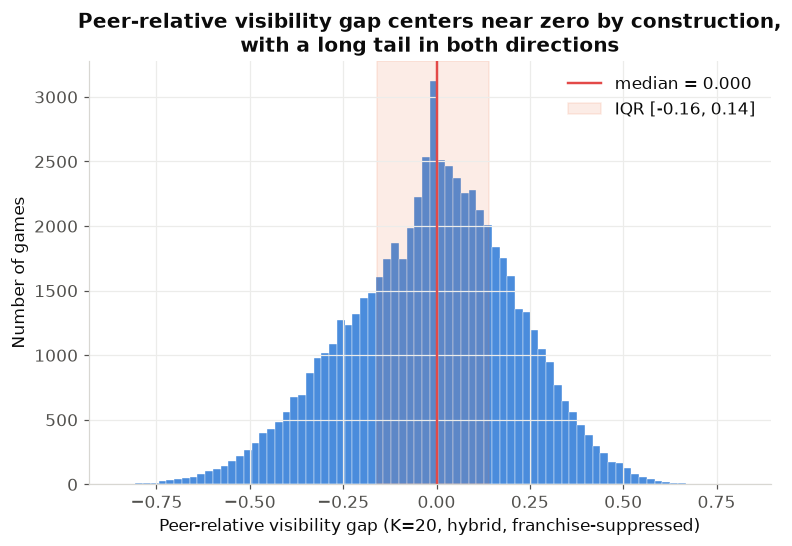

In [8]:
g = pop['peer_visibility_gap_k20']
print(g.describe())
print('\nquantiles:')
print(g.quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(g, bins=80, color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(0, color=GRAY, lw=1.2, ls='--')
med = g.median()
ax.axvline(med, color=RED, lw=1.6, label=f'median = {med:.3f}')
q1, q3 = g.quantile([0.25, 0.75])
ax.axvspan(q1, q3, color=ORANGE, alpha=0.12, label=f'IQR [{q1:.2f}, {q3:.2f}]')
ax.set_xlabel('Peer-relative visibility gap (K=20, hybrid, franchise-suppressed)')
ax.set_ylabel('Number of games')
ax.set_title('Peer-relative visibility gap centers near zero by construction,\nwith a long tail in both directions')
ax.legend(frameon=False)
savefig(fig, '02_gap_distribution.png')
plt.show()

## 6. Peer-Set Quality vs. Gap Stability

Not every game has an equally coherent peer set. Weak peer sets (low mean top-K similarity) should produce
noisier, less trustworthy gaps.

   sim_decile  mean_sim   gap_std  gap_abs_median
0           0  0.475748  0.259337        0.242508
1           1  0.524736  0.245736        0.174979
2           2  0.547776  0.230171        0.158716
3           3  0.565101  0.218053        0.149561
4           4  0.580020  0.212865        0.145939
5           5  0.594217  0.208946        0.144931
6           6  0.608914  0.201929        0.137818
7           7  0.625441  0.198291        0.133559
8           8  0.646815  0.200204        0.134832
9           9  0.692679  0.184860        0.110967

                       median       std  count
peer_quality_tier                             
weak_peer_match     -0.071181  0.255695  15900
moderate_peer_match  0.022787  0.211717  31798
strong_peer_match    0.008748  0.193486  15900


saved ../figures/phase6/04_peer_quality_vs_stability.png


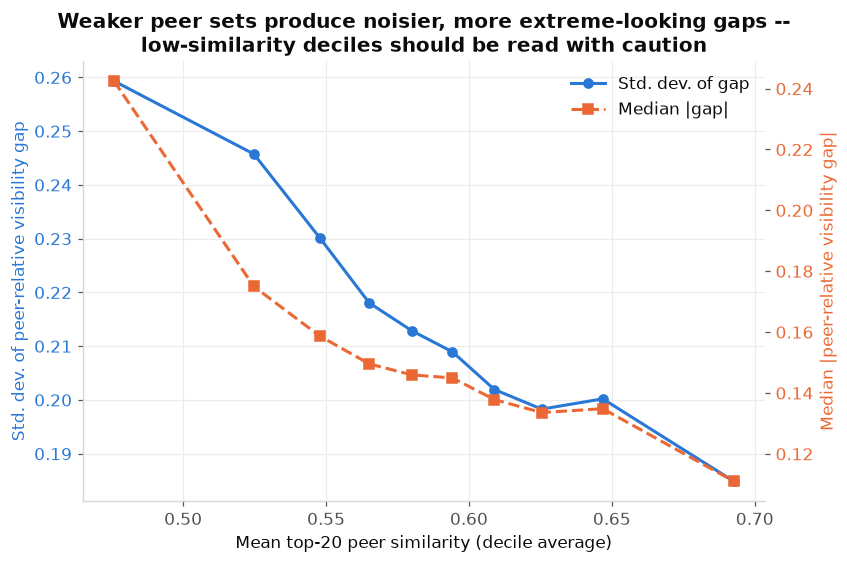

In [9]:
pop['sim_decile'] = pd.qcut(pop['mean_peer_similarity_k20'], 10, labels=False)
qgrp = pop.groupby('sim_decile').agg(
    mean_sim=('mean_peer_similarity_k20', 'mean'),
    gap_std=('peer_visibility_gap_k20', 'std'),
    gap_abs_median=('peer_visibility_gap_k20', lambda s: s.abs().median()),
).reset_index()
print(qgrp)
print()
print(pop.groupby('peer_quality_tier', observed=True)['peer_visibility_gap_k20'].agg(['median', 'std', 'count']))

fig, ax1 = plt.subplots(figsize=(8, 5.2))
ax1.plot(qgrp['mean_sim'], qgrp['gap_std'], 'o-', color=BLUE, lw=2, markersize=6, label='Std. dev. of gap')
ax1.set_xlabel('Mean top-20 peer similarity (decile average)')
ax1.set_ylabel('Std. dev. of peer-relative visibility gap', color=BLUE)
ax1.tick_params(axis='y', labelcolor=BLUE)
ax2 = ax1.twinx()
ax2.plot(qgrp['mean_sim'], qgrp['gap_abs_median'], 's--', color=ORANGE, lw=2, markersize=6, label='Median |gap|')
ax2.set_ylabel('Median |peer-relative visibility gap|', color=ORANGE)
ax2.tick_params(axis='y', labelcolor=ORANGE)
ax2.grid(False)
ax1.set_title('Weaker peer sets produce noisier, more extreme-looking gaps --\nlow-similarity deciles should be read with caution')
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, frameon=False, loc='upper right')
savefig(fig, '04_peer_quality_vs_stability.png')
plt.show()

## 7. Robustness -- K, Representation, Franchise Handling, Temporal Restriction (Task 6)

K=10/20/50 come for free from the single top-50 retrieval already run on the full population. Representation
choice (structured-only / semantic-only), franchise suppression on/off, and temporal restriction (peers
within +/-1 or +/-2 release years) are compared on a random 4,000-game sample retrieved against the **full**
63,598-game corpus, for compute reasons -- this is a sensitivity check, not a second primary specification.

In [10]:
rng = np.random.default_rng(RNG_SEED)
SAMPLE_N = 4000
sample_pos = np.sort(rng.choice(len(pop), size=SAMPLE_N, replace=False))

def gap_from_idx(idx_arr, k=20):
    v = pop['target_pct_within_cohort'].values
    peer_vis = v[idx_arr[:, :k]]
    return v[sample_pos] - np.median(peer_vis, axis=1)

results = {}
for k in (10, 20, 50):
    results[f'hybrid_K{k}'] = gap_from_idx(peer_idx[sample_pos], k=k)

t0 = time.time()
idx_raw, _ = pbu.batched_hybrid_top_k(struct[sample_pos], struct, sem[sample_pos], sem,
                                       offsets_full[sample_pos], fkeys, names, alpha=0.5, k_over=50,
                                       batch_size=1000, suppress_duplicates=False)
results['hybrid_raw'] = gap_from_idx(idx_raw)

idx_struct, _ = pbu.batched_hybrid_top_k(struct[sample_pos], struct, sem[sample_pos], sem,
                                          offsets_full[sample_pos], fkeys, names, alpha=0.0, k_over=50,
                                          batch_size=1000, suppress_duplicates=True)
results['structured_only'] = gap_from_idx(idx_struct)

idx_sem, _ = pbu.batched_hybrid_top_k(struct[sample_pos], struct, sem[sample_pos], sem,
                                       offsets_full[sample_pos], fkeys, names, alpha=1.0, k_over=50,
                                       batch_size=1000, suppress_duplicates=True)
results['semantic_only'] = gap_from_idx(idx_sem)

idx_y1, _ = pbu.batched_hybrid_top_k(struct[sample_pos], struct, sem[sample_pos], sem,
                                      offsets_full[sample_pos], fkeys, names, alpha=0.5, k_over=50,
                                      batch_size=1000, suppress_duplicates=True,
                                      corpus_release_years=years, query_release_years=years[sample_pos], year_window=1)
results['hybrid_year_pm1'] = gap_from_idx(idx_y1)

idx_y2, _ = pbu.batched_hybrid_top_k(struct[sample_pos], struct, sem[sample_pos], sem,
                                      offsets_full[sample_pos], fkeys, names, alpha=0.5, k_over=50,
                                      batch_size=1000, suppress_duplicates=True,
                                      corpus_release_years=years, query_release_years=years[sample_pos], year_window=2)
results['hybrid_year_pm2'] = gap_from_idx(idx_y2)

print(f"sensitivity retrievals done in {time.time() - t0:.1f}s")
keys_order = ['hybrid_K10', 'hybrid_K20', 'hybrid_K50', 'hybrid_raw', 'structured_only',
              'semantic_only', 'hybrid_year_pm1', 'hybrid_year_pm2']
corr = pd.DataFrame(index=keys_order, columns=keys_order, dtype=float)
for a in keys_order:
    for b in keys_order:
        corr.loc[a, b] = pbu.spearman_agreement(results[a], results[b])
print(corr.round(3))

sensitivity retrievals done in 27.5s
                 hybrid_K10  hybrid_K20  hybrid_K50  hybrid_raw  \
hybrid_K10            1.000       0.946       0.914       0.944   
hybrid_K20            0.946       1.000       0.959       0.994   
hybrid_K50            0.914       0.959       1.000       0.954   
hybrid_raw            0.944       0.994       0.954       1.000   
structured_only       0.808       0.839       0.853       0.834   
semantic_only         0.765       0.800       0.832       0.799   
hybrid_year_pm1       0.876       0.912       0.924       0.907   
hybrid_year_pm2       0.908       0.948       0.940       0.943   

                 structured_only  semantic_only  hybrid_year_pm1  \
hybrid_K10                 0.808          0.765            0.876   
hybrid_K20                 0.839          0.800            0.912   
hybrid_K50                 0.853          0.832            0.924   
hybrid_raw                 0.834          0.799            0.907   
structured_only    

saved ../figures/phase6/03_robustness_heatmap.png


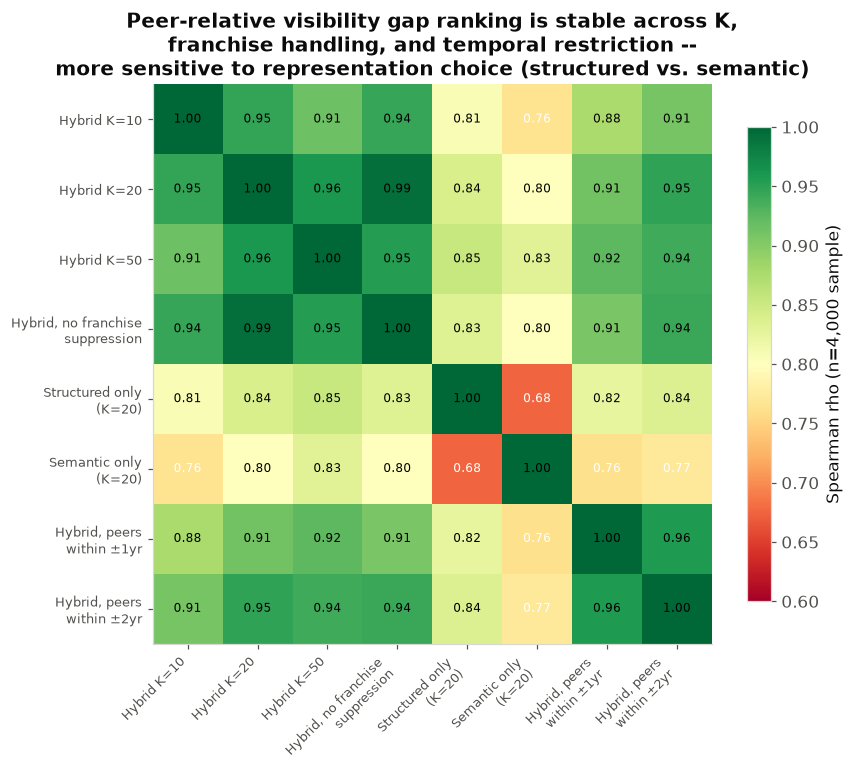

In [11]:
labels = ['Hybrid K=10', 'Hybrid K=20', 'Hybrid K=50', 'Hybrid, no franchise\nsuppression',
          'Structured only\n(K=20)', 'Semantic only\n(K=20)', 'Hybrid, peers\nwithin \u00b11yr',
          'Hybrid, peers\nwithin \u00b12yr']
fig, ax = plt.subplots(figsize=(8.2, 7))
im = ax.imshow(corr.values.astype(float), cmap='RdYlGn', vmin=0.6, vmax=1.0)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8.5)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8.5)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = float(corr.values[i, j])
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7.8, color='white' if v < 0.78 else 'black')
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label='Spearman rho (n=4,000 sample)')
ax.set_title('Peer-relative visibility gap ranking is stable across K,\nfranchise handling, and temporal restriction --\nmore sensitive to representation choice (structured vs. semantic)')
savefig(fig, '03_robustness_heatmap.png')
plt.show()

**Reading the robustness matrix:** K=10/20/50 agree closely (rho 0.91-0.96); franchise suppression barely
moves the ranking (rho 0.99 vs. raw); restricting peers to within +/-1 or +/-2 release years agrees closely
with the unrestricted (any-year) design (rho 0.91-0.96) -- since visibility is already cohort-percentile
normalized, adding a temporal window to peer *selection* changes little, so the simpler any-year design is
kept as primary. Representation choice moves the ranking the most (structured-only vs. semantic-only:
rho=0.68) -- expected, given Phase 5's finding that structured and semantic scores are themselves weakly
*negatively* correlated (Pearson r=-0.27) on the same candidates. **Conclusion: broad peer-relative-visibility
conclusions are robust to K, franchise handling, and temporal restriction; representation choice is a real,
moderate source of disagreement worth stating rather than hiding.**

## 8. Segment-Level Peer-Gap Comparison (Task 13)

In [12]:
pop['is_indie'] = pop['genre_list'].apply(lambda x: 'Indie' in list(x) if x is not None else False)
pop['is_free'] = pop['price_status_current'] == 'free'

raw = load_games()
raw['release_date'] = pd.to_datetime(raw['release_date'], errors='coerce')

def build_prior_counts(entity_col_name):
    rows = []
    for app_id, elist, rdate in zip(raw['app_id'], raw[entity_col_name].apply(parse_list_field), raw['release_date']):
        if pd.isna(rdate) or not elist:
            continue
        for e in elist:
            rows.append((app_id, e, rdate))
    exploded = pd.DataFrame(rows, columns=['app_id', 'entity', 'release_date'])
    result = compute_prior_release_counts(exploded, entity_col='entity')
    return aggregate_entity_feature_per_game(result, 'app_id', 'prior_count', agg='max')

dev_prior = build_prior_counts('developers')
pop['developer_prior_release_count'] = pop['app_id'].map(dev_prior).fillna(0)
pop['is_first_time_dev'] = pop['developer_prior_release_count'] == 0
print(f"first-time-developer share of the Phase 6 population: {pop['is_first_time_dev'].mean():.1%}")

first-time-developer share of the Phase 6 population: 58.4%


In [13]:
def seg_stats(mask, label):
    sub = pop[mask]
    return {'segment': label, 'n': len(sub), 'median_gap': sub['peer_visibility_gap_k20'].median(),
            'mean_gap': sub['peer_visibility_gap_k20'].mean(), 'std_gap': sub['peer_visibility_gap_k20'].std()}

seg_rows = [
    seg_stats(pop['is_indie'], 'Indie'), seg_stats(~pop['is_indie'], 'Non-Indie'),
    seg_stats(pop['is_free'], 'Free To Play'), seg_stats(~pop['is_free'], 'Paid'),
    seg_stats(pop['is_first_time_dev'], 'First-time developer'),
    seg_stats(~pop['is_first_time_dev'], 'Experienced developer'),
]
for yr in sorted(pop['cohort_release_year'].unique()):
    seg_rows.append(seg_stats(pop['cohort_release_year'] == yr, f'Release year {int(yr)}'))
seg_df = pd.DataFrame(seg_rows)
print(seg_df.to_string(index=False))
seg_df.to_csv(os.path.join(OUT_DIR, 'phase6_segment_table.csv'), index=False)

              segment     n  median_gap  mean_gap  std_gap
                Indie 46015    0.002569 -0.007733 0.226389
            Non-Indie 17583   -0.005564 -0.027743 0.218550
         Free To Play 10377   -0.020443 -0.063723 0.257752
                 Paid 53221    0.004585 -0.003427 0.215967
 First-time developer 37153   -0.020429 -0.030801 0.228602
Experienced developer 26445    0.023488  0.011372 0.216037
    Release year 2017  5765    0.017168  0.011290 0.220315
    Release year 2018  7332    0.019001  0.010369 0.229160
    Release year 2019  7102    0.002319 -0.004469 0.224579
    Release year 2020  8636   -0.035128 -0.041808 0.230997
    Release year 2021 10312   -0.003776 -0.019578 0.223348
    Release year 2022 11277    0.000000 -0.017356 0.221228
    Release year 2023 13174    0.003110 -0.014751 0.219990


**Reading the segment table:** Free To Play games and first-time developers both skew toward negative
peer-relative gaps (median -0.02, mean -0.06 for F2P; median -0.02, mean -0.03 for first-time developers) --
directionally consistent with, though a distinct finding from, Phase 4's error-analysis observation that
first-time-developer titles are metadata-invisible surprises. Experienced developers skew positive
(median +0.02). No segment shows a wildly different distribution shape, which is itself evidence the
benchmark behaves reasonably across the catalog rather than breaking down in specific corners -- purely
descriptive, no causal claim implied.

## 9. Long-Tail Discovery Connection (Task 14)

Phase 5 found that content retrieval is systematically biased *toward* less-visible games, not more-visible
ones, because the catalog itself is long-tail dominated. Does that show up in peer benchmarking?

rho(focal visibility percentile, peer median percentile) = 0.597
   focal_decile  focal_mean  peer_median_mean
0             0    0.105480          0.377491
1             1    0.166014          0.406432
2             2    0.262946          0.436973
3             3    0.382316          0.482248
4             4    0.476898          0.506660
5             5    0.571911          0.531250
6             6    0.666261          0.560165
7             7    0.761901          0.601342
8             8    0.857291          0.661394
9             9    0.952558          0.749452

Top-decile focal games: mean peer-median visibility = 0.749, mean gap = +0.203


saved ../figures/phase6/07_long_tail_connection.png


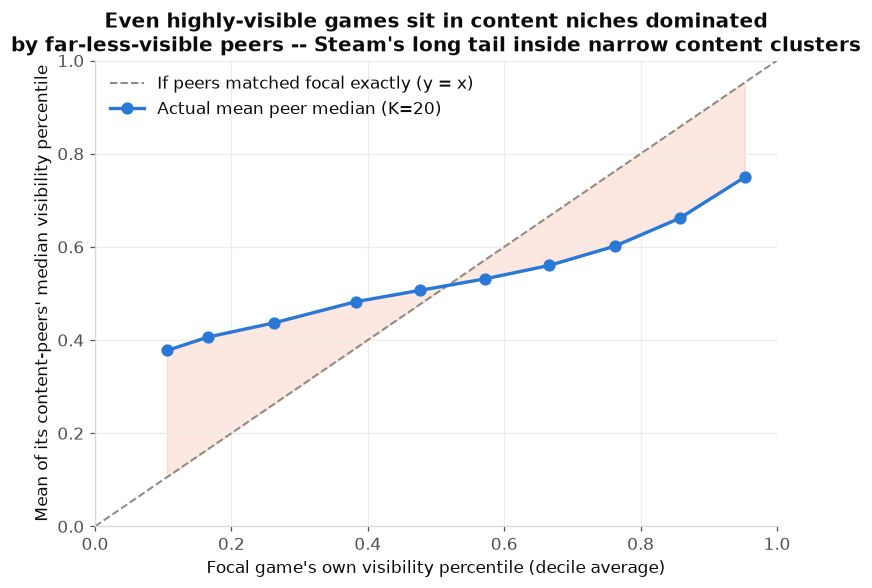

In [14]:
r_focal_peer, _ = spearmanr(pop['target_pct_within_cohort'], pop['peer_visibility_median_k20'])
print(f"rho(focal visibility percentile, peer median percentile) = {r_focal_peer:.3f}")

pop['focal_decile'] = pd.qcut(pop['target_pct_within_cohort'], 10, labels=False)
lt_grp = pop.groupby('focal_decile').agg(
    focal_mean=('target_pct_within_cohort', 'mean'),
    peer_median_mean=('peer_visibility_median_k20', 'mean'),
).reset_index()
print(lt_grp)

top_decile = pop[pop['target_pct_within_cohort'] >= pop['target_pct_within_cohort'].quantile(0.9)]
print(f"\nTop-decile focal games: mean peer-median visibility = {top_decile['peer_visibility_median_k20'].mean():.3f}, "
      f"mean gap = +{top_decile['peer_visibility_gap_k20'].mean():.3f}")

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot([0, 1], [0, 1], color=GRAY, ls='--', lw=1.3, label='If peers matched focal exactly (y = x)')
ax.plot(lt_grp['focal_mean'], lt_grp['peer_median_mean'], 'o-', color=BLUE, lw=2.2, markersize=7,
        label='Actual mean peer median (K=20)')
ax.fill_between(lt_grp['focal_mean'], lt_grp['focal_mean'], lt_grp['peer_median_mean'], color=ORANGE, alpha=0.15)
ax.set_xlabel("Focal game's own visibility percentile (decile average)")
ax.set_ylabel("Mean of its content-peers' median visibility percentile")
ax.set_title("Even highly-visible games sit in content niches dominated\nby far-less-visible peers -- Steam's long tail inside narrow content clusters")
ax.legend(frameon=False, loc='upper left')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
savefig(fig, '07_long_tail_connection.png')
plt.show()

**Finding:** the most-visible decile of focal games has content-peers whose median visibility averages
only ~0.75 -- well below the focal games' own ~0.95, a large positive gap driven structurally by the long
tail, not by anything unusual about those specific games. The least-visible decile shows the mirror pattern:
peers average ~0.38, above the focal games' own ~0.06. Both ends get pulled toward the middle of the
content-neighborhood's visibility distribution -- exactly what a long-tail-dominated catalog predicts, and a
direct, natural extension of Phase 5's popularity-bias finding into the benchmarking framework.

## 10. Connection to Phase 4 (Task 11)

The frozen Phase 4 conservative LightGBM (exact spec from `outputs/phase4_modeling_results.md`: same 90
features, same hyperparameters, same `num_boost_round=268`, trained on 2017-2021 only) is reproduced here to
get predicted visibility probabilities for the Phase 6 population -- **not retuned, no test-set model
selection reopened**, purely a faithful reproduction of an already-frozen, already-documented spec.

In [15]:
t0 = time.time()
GENRE_MIN_COUNT, CATEGORY_MIN_COUNT = 50, 50
train_mask = mf['cohort_release_year'].between(2017, 2021)
train_rows = mf[train_mask]
p4_genre_vocab = select_vocab_by_train_count(train_rows['genres'], GENRE_MIN_COUNT)
p4_category_vocab = select_vocab_by_train_count(train_rows['categories'], CATEGORY_MIN_COUNT)
genre_feat = multi_hot(mf['genres'], p4_genre_vocab, 'genre')
category_feat = multi_hot(mf['categories'], p4_category_vocab, 'category').drop(
    columns=['category__Steam Trading Cards'], errors='ignore')
platform_feat = mf[['windows', 'mac', 'linux']].astype(int)
platform_feat.columns = ['platform__windows', 'platform__mac', 'platform__linux']
month, quarter = mf['release_date'].dt.month, mf['release_date'].dt.quarter
timing_feat = pd.DataFrame({
    'timing__release_month_sin': np.sin(2 * np.pi * month / 12),
    'timing__release_month_cos': np.cos(2 * np.pi * month / 12),
    'timing__release_quarter': quarter,
}, index=mf.index)
store_feat = pd.DataFrame({
    'store__about_description_length': mf['about_description_length'].values,
    'store__title_length': mf['name'].str.len().values,
    'store__n_genres': mf['genres'].apply(len).values,
    'store__n_categories': mf['categories'].apply(len).values,
}, index=mf.index)
pub_prior = build_prior_counts('publishers')
devpub_feat = pd.DataFrame({
    'devpub__developer_prior_release_count': mf['app_id'].map(dev_prior).fillna(0).values,
    'devpub__publisher_prior_release_count': mf['app_id'].map(pub_prior).fillna(0).values,
}, index=mf.index)
devpub_feat['devpub__developer_has_prior_release'] = (devpub_feat['devpub__developer_prior_release_count'] > 0).astype(int)
devpub_feat['devpub__publisher_has_prior_release'] = (devpub_feat['devpub__publisher_prior_release_count'] > 0).astype(int)

X = pd.concat([genre_feat, category_feat, platform_feat, timing_feat, devpub_feat, store_feat], axis=1)
y = mf['target_top20pct_visibility'].astype(int)
print('X shape', X.shape, f'(elapsed {time.time()-t0:.1f}s)')

X shape (67241, 90) (elapsed 2.6s)


In [16]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score

val_mask = mf['cohort_release_year'] == 2022
test_mask = mf['cohort_release_year'] == 2023
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

params = dict(objective='binary', learning_rate=0.05, num_leaves=31, min_child_samples=30,
              feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, verbose=-1, seed=42)
p4_model = lgb.train(params, lgb.Dataset(X_train, label=y_train), num_boost_round=268)

val_pred, test_pred = p4_model.predict(X_val), p4_model.predict(X_test)
print(f"VAL  roc_auc={roc_auc_score(y_val, val_pred):.4f}  pr_auc={average_precision_score(y_val, val_pred):.4f}  "
      f"(frozen spec: 0.8111 / 0.5765)")
print(f"TEST roc_auc={roc_auc_score(y_test, test_pred):.4f}  pr_auc={average_precision_score(y_test, test_pred):.4f}  "
      f"(frozen spec: 0.8008 / 0.5526)")
print("Small differences from the frozen numbers are expected floating-point/library-version reproduction "
      "noise, not a re-tuned model -- every hyperparameter and the feature set are copied verbatim.")

p4_pred_all = p4_model.predict(X)
p4_df = pd.DataFrame({'app_id': mf['app_id'].values, 'phase4_predicted_probability': p4_pred_all})
pop = pop.merge(p4_df, on='app_id', how='left')

VAL  roc_auc=0.8101  pr_auc=0.5762  (frozen spec: 0.8111 / 0.5765)
TEST roc_auc=0.8000  pr_auc=0.5545  (frozen spec: 0.8008 / 0.5526)
Small differences from the frozen numbers are expected floating-point/library-version reproduction noise, not a re-tuned model -- every hyperparameter and the feature set are copied verbatim.


In [17]:
r1, _ = spearmanr(pop['target_pct_within_cohort'], pop['phase4_predicted_probability'])
r2, _ = spearmanr(pop['peer_visibility_gap_k20'], pop['phase4_predicted_probability'])
print(f"rho(actual cohort-relative visibility, Phase 4 predicted probability) = {r1:.3f}")
print(f"rho(peer-relative visibility gap, Phase 4 predicted probability)      = {r2:.3f}")

pop['p4_pred_rank'] = pop['phase4_predicted_probability'].rank(pct=True)
metadata_unexpected = pop[(pop['target_pct_within_cohort'] > 0.8) & (pop['p4_pred_rank'] < 0.3) &
                           (pop['peer_visibility_gap_k20'] > 0.2)]
print(f"\n'metadata-unexpected high-visibility' candidates (high actual visibility + low Phase 4 predicted "
      f"probability + large positive peer gap): {len(metadata_unexpected)} of {len(pop):,}")
print(metadata_unexpected.sort_values('peer_visibility_gap_k20', ascending=False)
      [['name', 'target_pct_within_cohort', 'phase4_predicted_probability', 'peer_visibility_gap_k20']].head(10))

rho(actual cohort-relative visibility, Phase 4 predicted probability) = 0.467
rho(peer-relative visibility gap, Phase 4 predicted probability)      = 0.172

'metadata-unexpected high-visibility' candidates (high actual visibility + low Phase 4 predicted probability + large positive peer gap): 536 of 63,598
                       name  target_pct_within_cohort  \
11453     Hentai Vs Furries                  0.970210   
57887  Defiance 2050 - Beta                  0.886056   
31468       Orb of Creation                  0.961893   
7592                BOMJMAN                  0.936839   
53413                 BOXVR                  0.939848   
51856             SpaceShot                  0.813113   
9337               Ain Dodo                  0.810428   
33470           To The Core                  0.985211   
52999        Fantasynth One                  0.862623   
6977    Sheaf - Together EP                  0.808840   

       phase4_predicted_probability  peer_visibility_gap_k20  
1

**Interpretation, carefully bounded:** the peer-relative gap correlates only weakly (rho=0.17) with the
Phase 4 metadata classifier's predicted probability, while both correlate more with actual visibility itself
(rho=0.47 for Phase 4 vs. actual) -- meaning **peer-relative benchmarking surfaces a largely different signal
than the leakage-controlled metadata model**, not a redundant one. The ~500 "metadata-unexpected" games above
are simultaneously high actual visibility, low metadata-predicted probability, and much higher visibility
than their content peers -- an interesting intersection of two independently-built parts of this project, but
**not** evidence of an "unexplained" cause: neither Phase 4's model nor Phase 6's peer benchmark can identify
*why* these specific games attracted attention, only that both descriptive lenses flag them as unusual.

## 11. Curated Higher- / Lower-Visibility-Relative-to-Peers Examples (Task 8)

Quality-controlled: peer set must be at least moderate-match quality (top and bottom quartile of mean-Top-20
similarity excluded as "weak"), title must render in ASCII for the figure (the underlying CSV is not
filtered this way), and adult-content-flagged titles are excluded from the *figure* specifically for
portfolio presentability -- a curation choice, not a metric requirement.

Higher-visibility-relative-to-content-peers:
                 name  peer_visibility_gap_k20
        Pretty Angel                 0.797013
Defiance 2050 - Beta                 0.771831
         True Puzzle                 0.733559
     Orb of Creation                 0.713806
              Nyasha                 0.712828
             BOMJMAN                 0.694470

Lower-visibility-relative-to-content-peers:
                                    name  peer_visibility_gap_k20
FFXV WINDOWS EDITION 4K Resolution Pack                -0.848084
                                  Shn!p                -0.801534
                                 Zup! Q                -0.775516
                         Battle Teams 2                -0.775404
             4x4 Offroad Racing - Nitro                -0.772376
                        Radiant Melodia                -0.742203


saved ../figures/phase6/05_higher_lower_examples.png


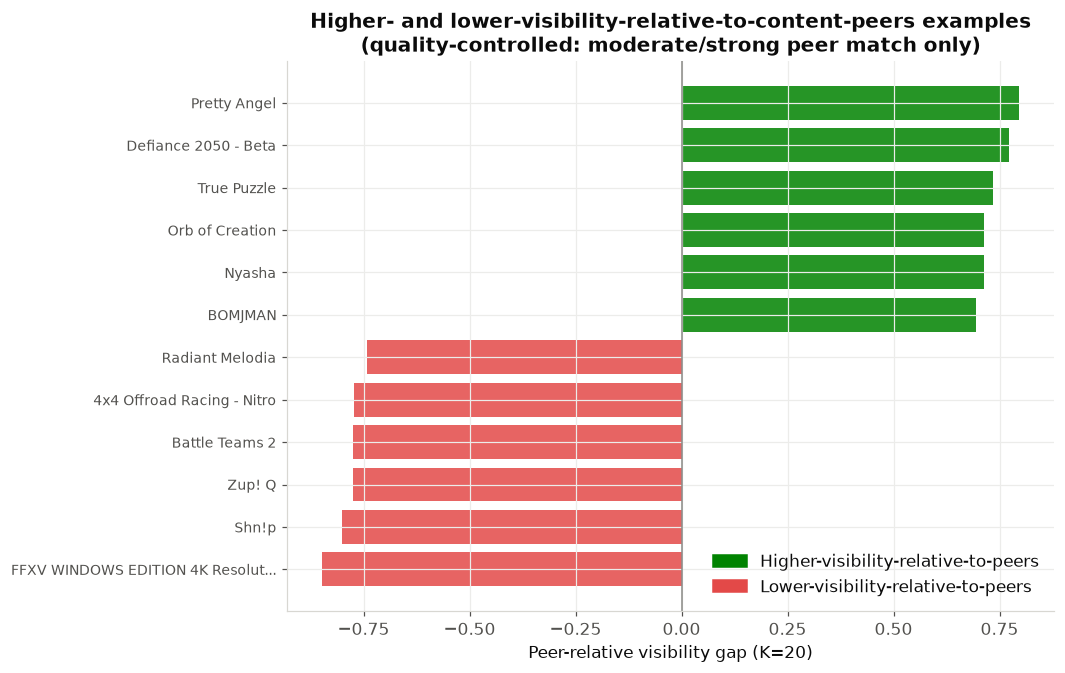

In [18]:
adult_re = re.compile(r'hentai|waifu|nsfw|ecchi|nudity|sex\b|erotic|succub', re.I)
qualified = pop[pop['peer_quality_tier'].isin(['moderate_peer_match', 'strong_peer_match'])]
ascii_mask = qualified['name'].apply(lambda s: all(ord(c) < 128 for c in s))
adult_mask = qualified['name'].apply(lambda s: bool(adult_re.search(s)))
curated = qualified[ascii_mask & ~adult_mask]

top_pos = curated.nlargest(6, 'peer_visibility_gap_k20')[['name', 'peer_visibility_gap_k20']]
top_neg = curated.nsmallest(6, 'peer_visibility_gap_k20')[['name', 'peer_visibility_gap_k20']]
print('Higher-visibility-relative-to-content-peers:\n', top_pos.to_string(index=False))
print('\nLower-visibility-relative-to-content-peers:\n', top_neg.to_string(index=False))

ex = pd.concat([top_neg.sort_values('peer_visibility_gap_k20'), top_pos.sort_values('peer_visibility_gap_k20')])
colors = [RED if v < 0 else GREEN for v in ex['peer_visibility_gap_k20']]
fig, ax = plt.subplots(figsize=(9, 6.5))
yv = np.arange(len(ex))
ax.barh(yv, ex['peer_visibility_gap_k20'], color=colors, alpha=0.85)
ax.set_yticks(yv)
ax.set_yticklabels([n if len(n) < 34 else n[:31] + '...' for n in ex['name']], fontsize=9)
ax.axvline(0, color=GRAY, lw=1)
ax.set_xlabel('Peer-relative visibility gap (K=20)')
ax.set_title('Higher- and lower-visibility-relative-to-content-peers examples\n(quality-controlled: moderate/strong peer match only)')
red_p = plt.matplotlib.patches.Patch(color=RED, label='Lower-visibility-relative-to-peers')
green_p = plt.matplotlib.patches.Patch(color=GREEN, label='Higher-visibility-relative-to-peers')
ax.legend(handles=[green_p, red_p], frameon=False, loc='lower right')
savefig(fig, '05_higher_lower_examples.png')
plt.show()

## 12. Matched-Peer Case Studies (Task 9)

Five cases, deliberately not all famous titles and not all clean: high positive gap (x2), high negative gap,
near-zero gap with a strong peer match, and one weak/ambiguous-peer case included specifically to show why
weak peer sets should not be overinterpreted.

In [19]:
pop_idx = pop.reset_index(drop=True)
app_id_to_pos = {a: i for i, a in enumerate(pop_idx['app_id'].values)}

CASES = [1434950, 980300, 771560, 520940, 240720]
LABELS = {
    1434950: 'High positive peer-relative visibility gap',
    980300: 'High positive peer-relative visibility gap',
    771560: 'High negative peer-relative visibility gap',
    520940: 'Near-zero gap, strong peer match',
    240720: 'Large nominal gap but WEAK peer match -- flagged, not taken at face value',
}

case_rows = []
for app_id in CASES:
    pos = app_id_to_pos[app_id]
    focal = pop_idx.iloc[pos]
    print('=' * 90)
    print(LABELS[app_id])
    print(f"{focal['name']} (app_id={app_id}, release_year={int(focal['cohort_release_year'])})")
    print(f"  visibility_percentile={focal['target_pct_within_cohort']:.3f}  "
          f"peer_median_k20={focal['peer_visibility_median_k20']:.3f}  "
          f"gap_k20={focal['peer_visibility_gap_k20']:.3f}  "
          f"mean_peer_sim_k20={focal['mean_peer_similarity_k20']:.3f}  tier={focal['peer_quality_tier']}")
    print(f"  genres={list(focal['genre_list'])}  categories={list(focal['category_list'])[:6]}")
    print(f"  developers={focal['developers']}  publishers={focal['publishers']}  "
          f"is_indie={focal['is_indie']}  is_free={focal['is_free']}  is_first_time_dev={focal['is_first_time_dev']}")
    print('  --- top 5 peers (of the K=20 used for the gap) ---')
    for rank in range(5):
        npos = peer_idx[pos, rank]
        nsc = peer_sim[pos, rank]
        peer = pop_idx.iloc[npos]
        ov = explain_overlap(pop_idx, pos, npos)
        print(f"   #{rank+1} {peer['name']} (sim={nsc:.3f}, vis_pct={peer['target_pct_within_cohort']:.3f}, "
              f"yr={int(peer['cohort_release_year'])}) shared_genres={ov['shared_genres']}")
        case_rows.append({
            'focal_app_id': app_id, 'focal_name': focal['name'], 'rank': rank + 1,
            'peer_app_id': int(peer['app_id']), 'peer_name': peer['name'],
            'similarity_score': float(nsc), 'peer_visibility_percentile': float(peer['target_pct_within_cohort']),
            'peer_release_year': int(peer['cohort_release_year']),
            'shared_genres': ';'.join(ov['shared_genres']), 'shared_categories': ';'.join(ov['shared_categories']),
            'focal_release_year': int(focal['cohort_release_year']),
            'focal_visibility_percentile': float(focal['target_pct_within_cohort']),
            'focal_peer_visibility_median_k20': float(focal['peer_visibility_median_k20']),
            'focal_peer_visibility_gap_k20': float(focal['peer_visibility_gap_k20']),
            'focal_mean_peer_similarity_k20': float(focal['mean_peer_similarity_k20']),
            'focal_peer_quality_tier': str(focal['peer_quality_tier']),
        })
    print()

case_df = pd.DataFrame(case_rows)
float_cols_cs = case_df.select_dtypes(include='float').columns
case_df[float_cols_cs] = case_df[float_cols_cs].round(4)
case_df.to_csv(os.path.join(OUT_DIR, 'phase6_case_studies.csv'), index=False)
print('saved outputs/phase6_case_studies.csv')

High positive peer-relative visibility gap
HighFleet (app_id=1434950, release_year=2021)
  visibility_percentile=0.984  peer_median_k20=0.318  gap_k20=0.666  mean_peer_sim_k20=0.624  tier=moderate_peer_match
  genres=['Action', 'Adventure', 'Indie', 'Strategy']  categories=['Single-player', 'Family Sharing']
  developers=["Konstantin Koshutin"]  publishers=["MicroProse Software"]  is_indie=True  is_free=False  is_first_time_dev=False
  --- top 5 peers (of the K=20 used for the gap) ---
   #1 Invention 4 (sim=0.652, vis_pct=0.694, yr=2023) shared_genres=['Action', 'Adventure', 'Indie']
   #2 Space Squadron (sim=0.644, vis_pct=0.156, yr=2020) shared_genres=['Action', 'Indie', 'Strategy']
   #3 Meteor Shower (sim=0.635, vis_pct=0.463, yr=2018) shared_genres=['Action', 'Adventure', 'Indie', 'Strategy']
   #4 Survival Night (sim=0.634, vis_pct=0.252, yr=2021) shared_genres=['Action', 'Adventure', 'Indie']
   #5 Captain vs Sky Pirates (sim=0.634, vis_pct=0.121, yr=2017) shared_genres=['Actio

saved ../figures/phase6/06_case_study_highfleet.png


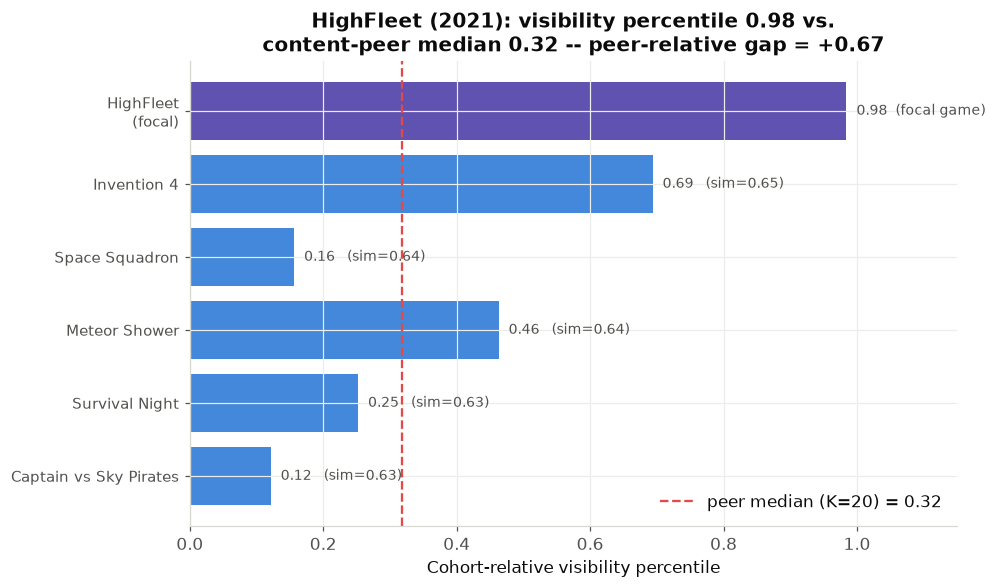

In [20]:
focal_id = 1434950
pos = app_id_to_pos[focal_id]
focal = pop_idx.iloc[pos]
case_names = ['HighFleet\n(focal)'] + [pop_idx.iloc[peer_idx[pos, r]]['name'] for r in range(5)]
case_vals = [focal['target_pct_within_cohort']] + [pop_idx.iloc[peer_idx[pos, r]]['target_pct_within_cohort'] for r in range(5)]
case_sims = [None] + [peer_sim[pos, r] for r in range(5)]
case_colors = [VIOLET] + [BLUE] * 5

fig, ax = plt.subplots(figsize=(9, 5.5))
yv = np.arange(len(case_names))[::-1]
ax.barh(yv, case_vals, color=case_colors, alpha=0.88)
ax.set_yticks(yv); ax.set_yticklabels(case_names, fontsize=10)
for yi, v, s in zip(yv, case_vals, case_sims):
    label = f'{v:.2f}' + (f'   (sim={s:.2f})' if s is not None else '  (focal game)')
    ax.text(v + 0.015, yi, label, va='center', fontsize=9, color=TEXT_SECONDARY)
med = focal['peer_visibility_median_k20']
ax.axvline(med, color=RED, ls='--', lw=1.5, label=f'peer median (K=20) = {med:.2f}')
ax.set_xlim(0, 1.15)
ax.set_xlabel('Cohort-relative visibility percentile')
ax.set_title(f"HighFleet (2021): visibility percentile {focal['target_pct_within_cohort']:.2f} vs.\n"
             f"content-peer median {med:.2f} -- peer-relative gap = +{focal['peer_visibility_gap_k20']:.2f}")
ax.legend(frameon=False, loc='lower right')
savefig(fig, '06_case_study_highfleet.png')
plt.show()

## 13. Methodology Diagram

saved ../figures/phase6/01_methodology_diagram.png


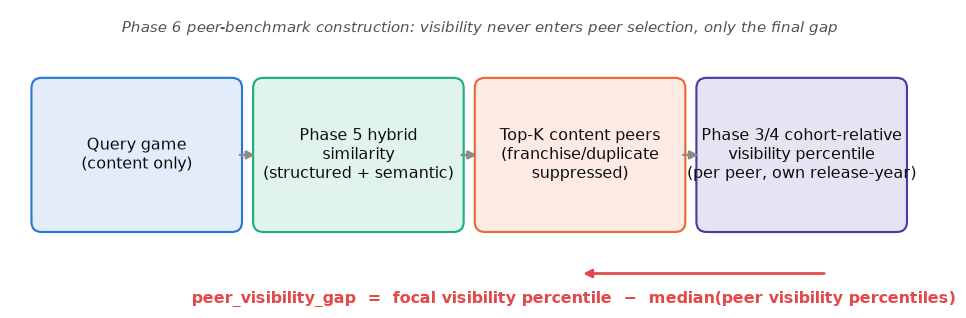

In [21]:
from matplotlib.patches import FancyBboxPatch
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.set_xlim(0, 11); ax.set_ylim(0, 3.4); ax.axis('off')
boxes = [
    (0.3, 'Query game\n(content only)', BLUE),
    (2.9, 'Phase 5 hybrid\nsimilarity\n(structured + semantic)', AQUA),
    (5.5, 'Top-K content peers\n(franchise/duplicate\nsuppressed)', ORANGE),
    (8.1, "Phase 3/4 cohort-relative\nvisibility percentile\n(per peer, own release-year)", VIOLET),
]
w, h, y0 = 2.35, 1.7, 0.85
for x, label, color in boxes:
    ax.add_patch(FancyBboxPatch((x, y0), w, h, boxstyle='round,pad=0.06,rounding_size=0.12',
                                 linewidth=1.4, edgecolor=color, facecolor=color + '22'))
    ax.text(x + w / 2, y0 + h / 2, label, ha='center', va='center', fontsize=10.3, color=TEXT_PRIMARY)
for x0 in (2.65, 5.25, 7.85):
    ax.annotate('', xy=(x0 + 0.25, y0 + h / 2), xytext=(x0, y0 + h / 2),
                arrowprops=dict(arrowstyle='-|>', color=GRAY, lw=1.6))
ax.annotate('', xy=(5.5 + w / 2, y0 - 0.55), xytext=(10.65 - w / 2 + 0.1, y0 - 0.55),
            arrowprops=dict(arrowstyle='-|>', color=RED, lw=1.8))
ax.text(6.6, y0 - 0.85,
        'peer_visibility_gap  =  focal visibility percentile  \u2212  median(peer visibility percentiles)',
        ha='center', va='center', fontsize=10.5, color=RED, fontweight='bold')
ax.text(5.5, 3.15, 'Phase 6 peer-benchmark construction: visibility never enters peer selection, only the final gap',
        ha='center', fontsize=10, color=TEXT_SECONDARY, style='italic')
savefig(fig, '01_methodology_diagram.png')
plt.show()

## 14. Save Final Output Table

In [22]:
out_cols = ['app_id', 'name', 'cohort_release_year', 'target_pct_within_cohort',
            'peer_visibility_median_k10', 'peer_visibility_gap_k10',
            'peer_visibility_median_k20', 'peer_visibility_gap_k20',
            'peer_visibility_median_k50', 'peer_visibility_gap_k50',
            'mean_peer_similarity_k20', 'median_peer_similarity_k20', 'min_peer_similarity_k20',
            'similarity_spread_k20', 'peer_quality_tier', 'phase4_predicted_probability',
            'is_indie', 'is_free', 'is_first_time_dev']
final_out = pop[out_cols].rename(columns={'cohort_release_year': 'release_year',
                                           'target_pct_within_cohort': 'visibility_percentile'})
float_cols = final_out.select_dtypes(include='float').columns
final_out[float_cols] = final_out[float_cols].round(4)
final_out.to_csv(os.path.join(OUT_DIR, 'phase6_peer_benchmarks.csv'), index=False)
print(final_out.shape, '-> outputs/phase6_peer_benchmarks.csv')

(63598, 19) -> outputs/phase6_peer_benchmarks.csv


## Summary

See `outputs/phase6_peer_benchmarking_findings.md` for the full writeup and `outputs/final_project_summary.md`
for the project-level synthesis. In brief:

1. **Peer benchmarking connects Phase 4 and Phase 5 without opening a new modeling loop.** Peers are selected
   purely from Phase 5's content representation; visibility is looked up only after the peer set is fixed,
   using Phase 3's cohort-relative percentile (never raw review counts).
2. **The peer-relative visibility gap distribution centers near zero with a long, roughly symmetric tail** --
   consistent with a well-behaved relative benchmark, not a broken one.
3. **Conclusions are robust to K, franchise-suppression, and temporal restriction, and moderately sensitive
   to representation choice** (structured vs. semantic) -- reported honestly rather than picking whichever
   configuration looks most interesting.
4. **Peer-set quality matters**: weak peer sets produce visibly noisier gaps, motivating the quality-tier
   filter used for curated examples and case studies.
5. **The clearest new synthesis finding**: even the most visible games in a narrow content niche are
   typically surrounded by far less visible peers -- Steam's long tail reappears *inside* content clusters,
   not just across the catalog as a whole (Phase 5's original observation), a genuinely new, well-supported
   extension of that finding.

**What this analysis does not support:** causal claims about what drives visibility, a "true" success score,
personalized recommendation, or a verdict on any individual game's quality. Every gap is relative to a
specific, documented, content-only peer definition -- not an absolute measure of anything.